In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
#Get the S&P5 prices
sp500 = yf.download("^GSPC", period="max")

[*********************100%***********************]  1 of 1 completed


In [3]:
print(sp500.head())

Price           Close       High        Low       Open Volume
Ticker          ^GSPC      ^GSPC      ^GSPC      ^GSPC  ^GSPC
Date                                                         
1927-12-30  17.660000  17.660000  17.660000  17.660000      0
1928-01-03  17.760000  17.760000  17.760000  17.760000      0
1928-01-04  17.719999  17.719999  17.719999  17.719999      0
1928-01-05  17.549999  17.549999  17.549999  17.549999      0
1928-01-06  17.660000  17.660000  17.660000  17.660000      0


In [4]:
def plot_closing_prices(data, title="Closing Prices [USD]", xlabel="Date", ylabel="Closing Price [USD]"):
    fig, ax = plt.subplots()
    ax.plot(data.index, data["Close"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()

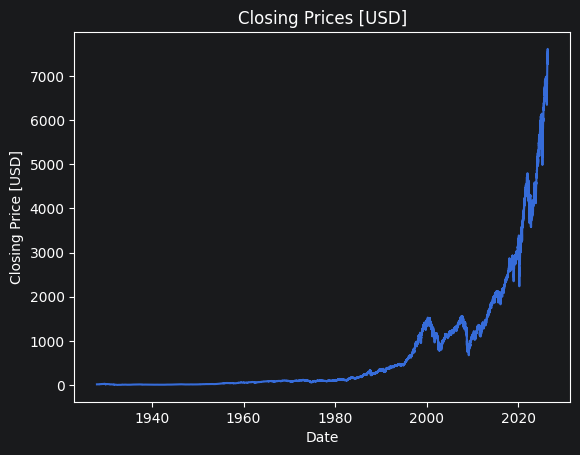

In [5]:
plot_closing_prices(sp500)

In [6]:
def plot_closing_prices_log2(data, title="Closing Prices [USD] / log2 Transformed", xlabel="Date", ylabel="log2(Price [USD])"):
    data["CloseLog2"] = np.log2(data["Close"])
    fig, ax = plt.subplots()
    ax.plot(data.index, data["CloseLog2"])
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.show()

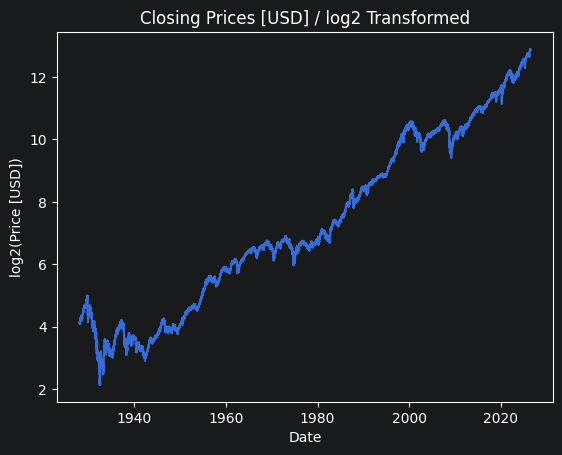

In [7]:
plot_closing_prices_log2(sp500)

In [8]:
def mark_dip(data, dip=30):
    close_prices = (data["Close"]["^GSPC"])
    dip_column = []
    highest_close_price = close_prices.iloc[0]
    for close_price in close_prices:
        if close_price <= highest_close_price*(1-dip/100):
            dip_column.append(True)
        else:
            dip_column.append(False)
        if close_price > highest_close_price:
            highest_close_price = close_price
    data["dip"] = dip_column
    return data

In [9]:
def plot_closing_prices_dip(data, dip=30, title="Closing Prices [USD]", xlabel="Date", ylabel="Price [USD]"):
    data = mark_dip(data, dip=dip)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.plot(
        data.index,
        data["Close"].where(~data["dip"]),
        color="green",
        label="Normal"
    )
    ax.plot(
        data.index,
        data["Close"].where(data["dip"]),
        color="red",
        label=f"{dip}% Dip"
    )
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    plt.show()

def plot_closing_prices_dip_log2(data, dip=30, title="Closing Prices [USD] / log2 Transformed", xlabel="Date", ylabel="log2(Price [USD])"):
    data = mark_dip(data, dip=dip)

    fig, ax = plt.subplots(figsize=(12, 6))
    data["CloseLog2"] = np.log2(data["Close"])

    ax.plot(
        data.index,
        data["CloseLog2"].where(~data["dip"]),
        color="green",
        label="Normal"
    )

    ax.plot(
        data.index,
        data["CloseLog2"].where(data["dip"]),
        color="red",
        label=f"{dip}% Dip"
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.legend()

    plt.show()

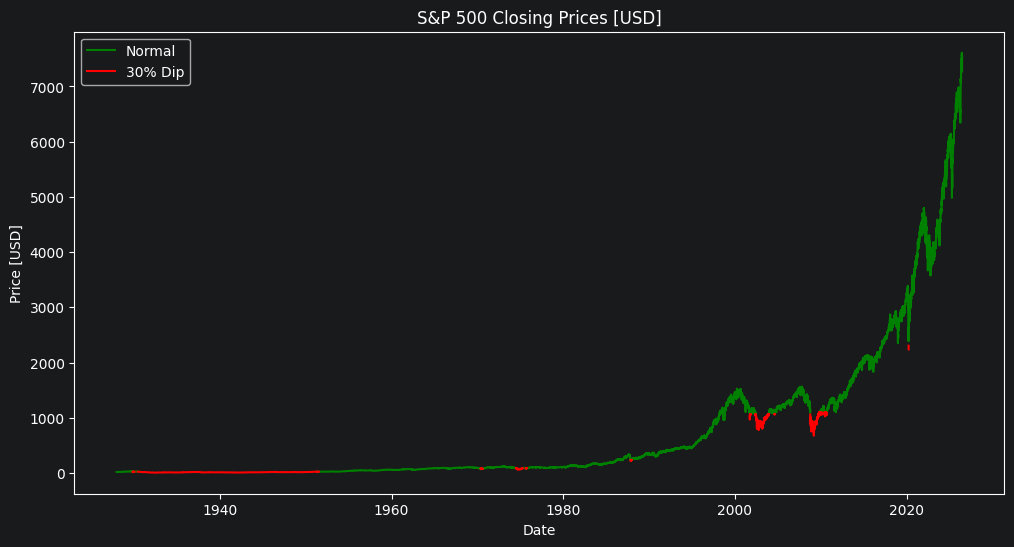

In [10]:
plot_closing_prices_dip(sp500, dip=30, title="S&P 500 Closing Prices [USD]")

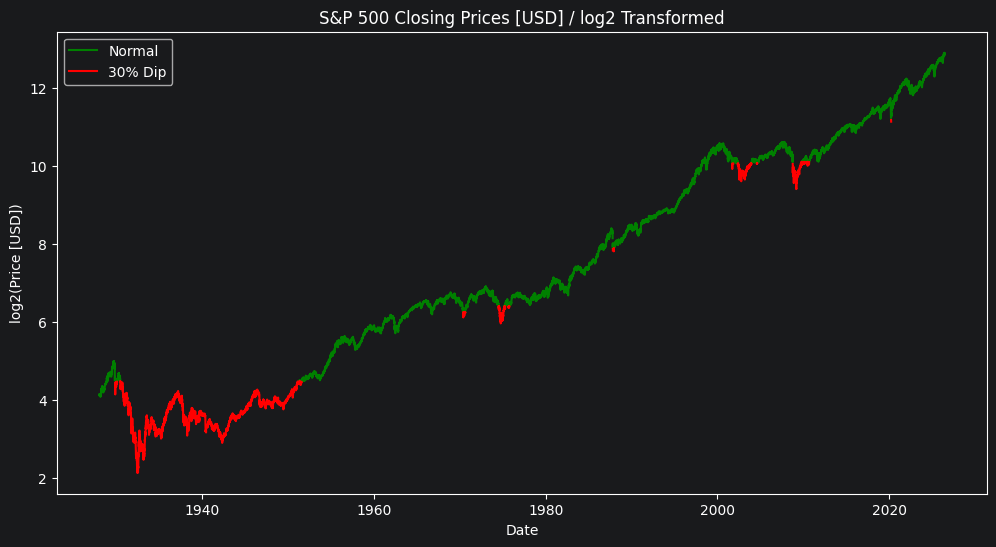

In [11]:
plot_closing_prices_dip_log2(sp500, dip=30, title="S&P 500 Closing Prices [USD] / log2 Transformed")

In [12]:
interest_rates = pd.read_csv(r"data/FEDFUNDS.csv")

In [13]:
print(interest_rates.head())

  observation_date  FEDFUNDS
0       1954-07-01      0.80
1       1954-08-01      1.22
2       1954-09-01      1.07
3       1954-10-01      0.85
4       1954-11-01      0.83


In [14]:
def vis_fedfund_rate(interest_rates, title="Federal Interest Rates", xlabel="Year", ylabel="Interest Rates [%]"):
    interest_rates = interest_rates.copy()
    interest_rates["observation_date"] = pd.to_datetime(
        interest_rates["observation_date"]
    )

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        interest_rates["observation_date"],
        interest_rates["FEDFUNDS"]
    )

    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.set_ylabel(ylabel)
    ax.set_xlabel(xlabel)
    ax.set_title(title)

    plt.xticks(rotation=45)
    plt.show()

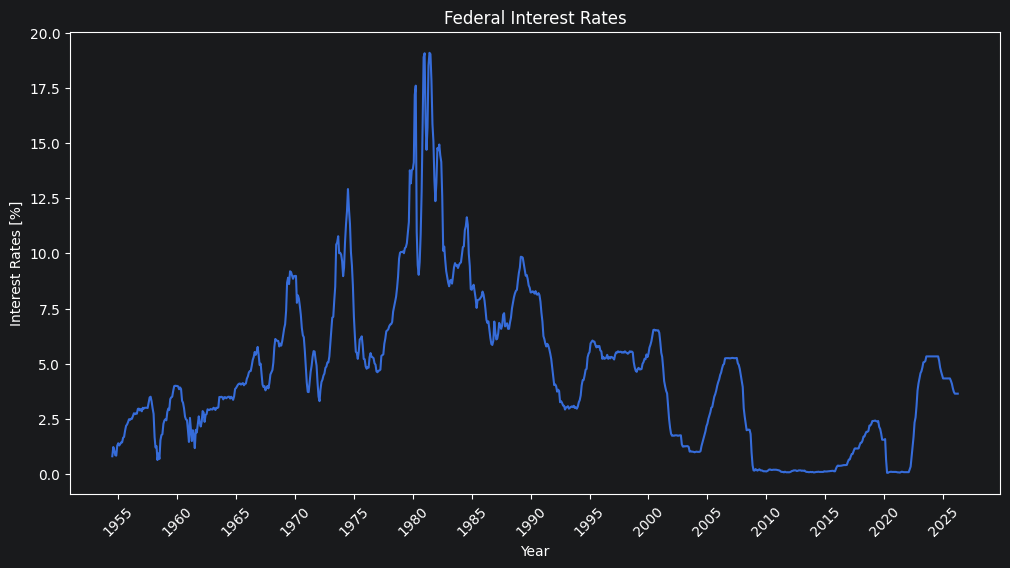

In [15]:
vis_fedfund_rate(interest_rates)

In [16]:
def calculate_interest(interest_rates, start_date, end_date):
    interest_rates = interest_rates.copy()
    interest_rates["observation_date"] = pd.to_datetime(interest_rates["observation_date"])
    interest_rates["FEDFUNDS"] = pd.to_numeric(interest_rates["FEDFUNDS"])

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    growth = 1.0

    interest_rates = interest_rates[
        (interest_rates["observation_date"] <= end_date) &
        (interest_rates["observation_date"] + pd.offsets.MonthEnd(0) >= start_date)
    ]

    for i in range(len(interest_rates)):
        month_start = interest_rates["observation_date"].iloc[i].replace(day=1)
        days_in_month = month_start.days_in_month
        month_end = month_start.replace(day=days_in_month)

        overlap_start = max(start_date, month_start)
        overlap_end = min(end_date, month_end)

        active_days = (overlap_end - overlap_start).days + 1
        fraction_of_month = active_days/days_in_month

        monthly_rate = interest_rates["FEDFUNDS"].iloc[i] / 100 / 12

        growth = growth * (1 + monthly_rate *fraction_of_month)

    return (growth-1)*100

In [17]:
calculate_interest(interest_rates, "2024-01-01", "2024-03-20")

np.float64(1.1794165671086265)

In [18]:
def calculate_performance(data, start_date, end_date):
    data = data.copy()

    data.index = pd.to_datetime(data.index)

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    period = data.loc[
        (data.index >= start_date) &
        (data.index <= end_date)
    ]

    start_price = period["Close"].iloc[0].squeeze()
    end_price = period["Close"].iloc[-1].squeeze()

    return_pct = (end_price / start_price - 1) * 100

    return float(return_pct)

In [19]:
calculate_performance(sp500, "2024-01-01", "2024-03-20")

10.158281682589143

In [20]:
def plot_closing_prices(data, start_date=None, end_date=None, log2_transform=False, title=None, xlabel="Date", ylabel="Price [USD]", normalize_to=None):
    data = data.copy()
    data.index = pd.to_datetime(data.index)

    if start_date is not None:
        start_date = pd.to_datetime(start_date)
        data = data.loc[data.index >= start_date]

    if end_date is not None:
        end_date = pd.to_datetime(end_date)
        data = data.loc[data.index <= end_date]

    if normalize_to is not None:
        data["Close"] = data["Close"] / data["Close"].iloc[0] * normalize_to

    fig, ax = plt.subplots(figsize=(12, 6))

    if log2_transform:
        values = np.log2(data["Close"])
        ylabel = f"log2({ylabel})"

        if title is None:
            title = "Closing Prices [USD] / log2 Transformed"

    else:
        values = data["Close"]

        if title is None:
            title = "Closing Prices [USD]"

    ax.plot(data.index, values)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    plt.show()

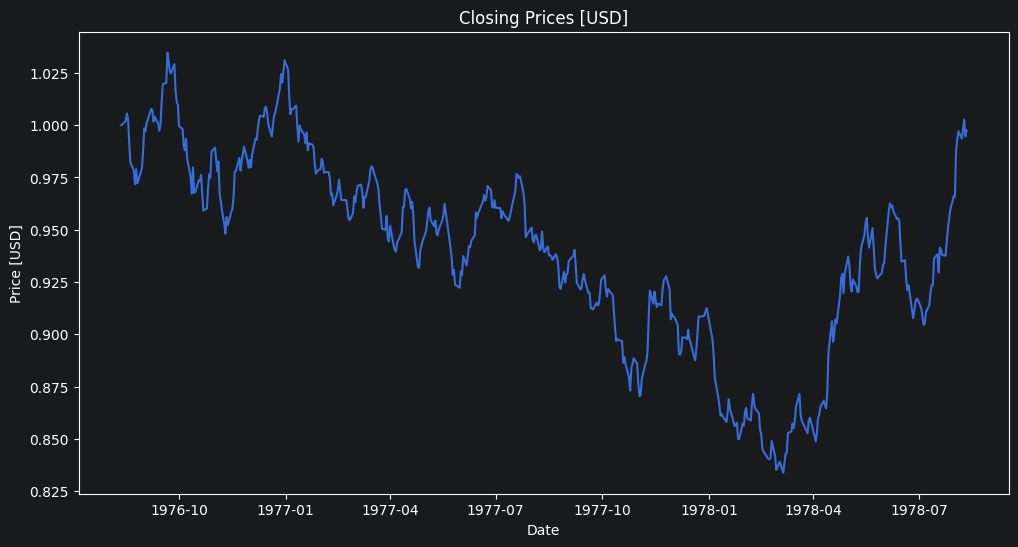

In [21]:
plot_closing_prices(sp500, start_date="1976-08-12", end_date="1978-08-12", normalize_to=1)

In [22]:
def plot_interest(interest_rates, start_date, end_date, normalize_to=1.0):
    interest_rates = interest_rates.copy()
    interest_rates["observation_date"] = pd.to_datetime(interest_rates["observation_date"])
    interest_rates["FEDFUNDS"] = pd.to_numeric(interest_rates["FEDFUNDS"])

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    interest_rates = interest_rates[
        (interest_rates["observation_date"] <= end_date) &
        (interest_rates["observation_date"] + pd.offsets.MonthEnd(0) >= start_date)
    ]

    collection_date = [start_date]
    accumulated_capital = [normalize_to]

    for i in range(len(interest_rates)):
        month_start = interest_rates["observation_date"].iloc[i].replace(day=1)
        days_in_month = month_start.days_in_month
        month_end = month_start.replace(day=days_in_month)

        overlap_start = max(start_date, month_start)
        overlap_end = min(end_date, month_end)

        active_days = (overlap_end - overlap_start).days + 1
        fraction_of_month = active_days/days_in_month

        monthly_rate = interest_rates["FEDFUNDS"].iloc[i] / 100 / 12

        collection_date.append(overlap_end)
        accumulated_capital.append(accumulated_capital[-1] * (1 + monthly_rate * fraction_of_month))

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.step(
        collection_date,
        accumulated_capital,
        where="post"
    )
    plt.show()


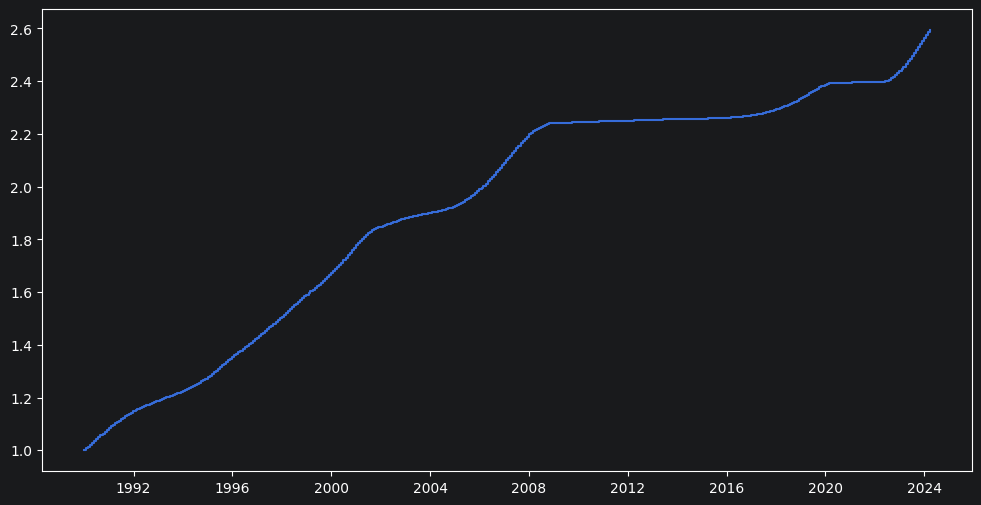

In [23]:
plot_interest(interest_rates, "1990-01-01", "2024-03-20")

In [24]:
calculate_interest(interest_rates, "1990-01-01", "2024-03-20")

np.float64(159.3025513875315)

In [25]:
sp500_dip = mark_dip(sp500, 30)

In [26]:
def cleanse_insta_dip(data):
    data = data.copy()

    for i in range(len(data)):

        if data["dip"].iloc[i]:
            data.loc[data.index[i], "dip"] = False
        else:
            break

    return data

In [27]:
def dip_strategy_plot(data, interest_rates, start_date, end_date, log2_transform=False, cleanse_dip=False):
    data = data.copy()
    interest_rates = interest_rates.copy()

    data.index = pd.to_datetime(data.index)

    interest_rates["observation_date"] = pd.to_datetime(
        interest_rates["observation_date"]
    )
    interest_rates["FEDFUNDS"] = pd.to_numeric(
        interest_rates["FEDFUNDS"]
    )

    start_date = pd.to_datetime(start_date)
    end_date = pd.to_datetime(end_date)

    data = data.loc[
        (data.index >= start_date) &
        (data.index <= end_date)
    ]

    interest_rates = interest_rates[
        (interest_rates["observation_date"] <= end_date) &
        (interest_rates["observation_date"] + pd.offsets.MonthEnd(0) >= start_date)
    ]

    if cleanse_dip:
        data = cleanse_insta_dip(data)

    collection_date = [start_date]
    accumulated_capital = [1.0]

    dip_date = None

    for date in data.index:
        if data.loc[date, "dip"]:
            dip_date = date
            break

    if dip_date is None:
        dip_date = end_date

    for i in range(len(interest_rates)):
        month_start = interest_rates["observation_date"].iloc[i].replace(day=1)
        days_in_month = month_start.days_in_month
        month_end = month_start.replace(day=days_in_month)

        overlap_start = max(start_date, month_start)
        overlap_end = min(dip_date, month_end)

        if overlap_end < overlap_start:
            continue

        active_days = (overlap_end - overlap_start).days + 1
        fraction_of_month = active_days / days_in_month

        monthly_rate = interest_rates["FEDFUNDS"].iloc[i] / 100 / 12

        collection_date.append(overlap_end)

        accumulated_capital.append(
            accumulated_capital[-1] *
            (1 + monthly_rate * fraction_of_month)
        )

    if dip_date != end_date:

        invested_capital = accumulated_capital[-1]
        buy_price = data["Close"]["^GSPC"].loc[dip_date]
        invested_data = data.loc[dip_date:]

        for date in invested_data.index[1:]:

            collection_date.append(date)

            accumulated_capital.append(
                invested_capital *
                data["Close"]["^GSPC"].loc[date] /
                buy_price
            )

    start_price = data["Close"]["^GSPC"].iloc[0]

    just_invest = (
        data["Close"]["^GSPC"] /
        start_price
    )

    if log2_transform:
        accumulated_capital_plot = np.log2(
            np.array(accumulated_capital)
        )

        just_invest_plot = np.log2(
            just_invest
        )

        ylabel = "log2(Capital)"
        title = "Dip Strategy vs Just Invest / log2 Transformed"

    else:
        accumulated_capital_plot = accumulated_capital
        just_invest_plot = just_invest
        ylabel = "Capital"
        title = "Dip Strategy vs Just Invest"

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        collection_date,
        accumulated_capital_plot,
        label="Dip strategy"
    )

    ax.plot(
        data.index,
        just_invest_plot,
        label="Just invest"
    )

    if dip_date != end_date:
        ax.axvline(
            dip_date,
            linestyle="--",
            label="Dip date"
        )

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.legend()

    plt.show()

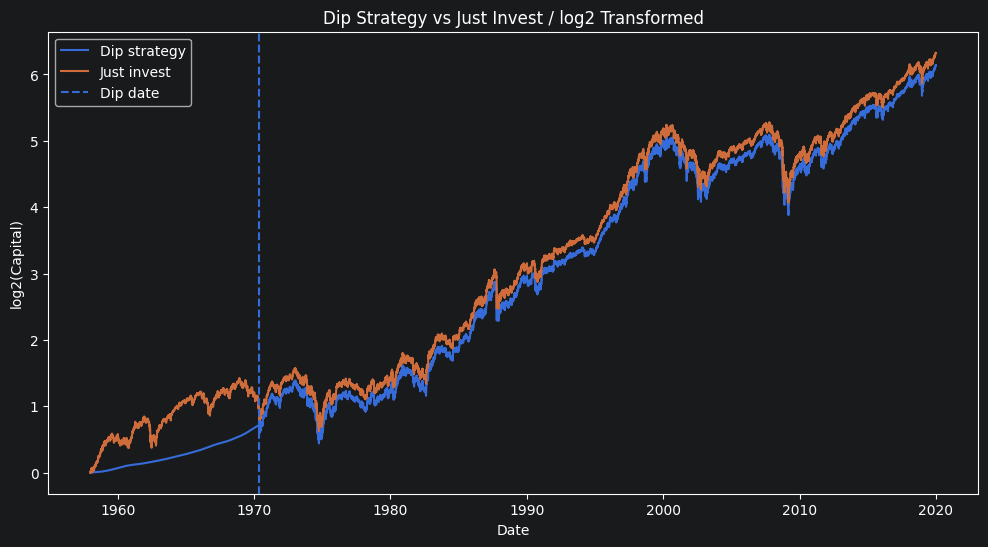

In [28]:
dip_strategy_plot(sp500_dip, interest_rates, "1958-01-01", "2020-01-01", log2_transform=True, cleanse_dip=True)